In [ ]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from src.training import (
    train_resnet, loss_fn_resnet, loss_fn_fa_resnet,
    loss_fn_ea_resnet, loss_fn_da_resnet, DEFAULT_CONFIG_RESNET,
)
from src.teacher import make_wi_particles_resnet, make_arbitrary_particles_resnet
from src.metrics import rmd_to_projected
import src.spaces as spaces

spaces.SETUP = spaces.make_setup_matrix()

L_VALUES = [1, 10, 100, 500]  # ResNet depth (1 skip connection)
N = 5
#N_VALUES = [5, 10, 50, 100, 500]
N_REPS = 3
CONFIG = {**DEFAULT_CONFIG_RESNET, "T": 2.0, "gr": 5}
CONFIG['beta'] = 0.0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
teacher_wi = make_wi_particles_resnet(1)

results_wi = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_wi:
        results_wi[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        # Vanilla
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_wi["vanilla"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        # DA
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_wi["DA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        # FA
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_wi["FA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        # EA
        h = train_resnet(teacher_wi, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        results_wi["EA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

    print(f"N={N} done")

N=5 done
N=5 done
N=5 done
N=5 done


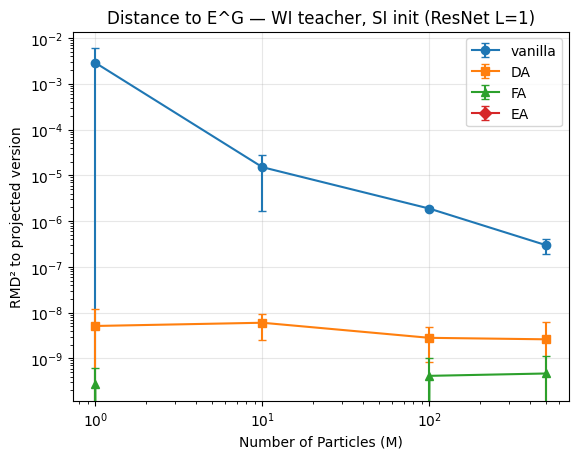

In [22]:
markers = {"vanilla": "o", "DA": "s", "FA": "^", "EA": "D"}

for name in results_wi:
    means = [jnp.mean(jnp.array(r)) for r in results_wi[name]]
    stds = [jnp.std(jnp.array(r)) for r in results_wi[name]]
    plt.errorbar(L_VALUES, means, yerr=stds, marker=markers[name],
                 label=name, capsize=3)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of Particles (M)")
plt.ylabel("RMD² to projected version")
plt.title("Distance to E^G — WI teacher, SI init (ResNet L=1)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [23]:
teacher_arb = make_arbitrary_particles_resnet(1)

results_arb = {"vanilla": [], "DA": [], "FA": [], "EA": []}

for L in L_VALUES:
    for name in results_arb:
        results_arb[name].append([])

    for rep in range(N_REPS):
        key = jax.random.PRNGKey(rep * 1000 + N)

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 0), CONFIG, "si")
        results_arb["vanilla"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 1), CONFIG, "si", used_loss_fn=loss_fn_da_resnet)
        results_arb["DA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 2), CONFIG, "si", used_loss_fn=loss_fn_fa_resnet)
        results_arb["FA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

        h = train_resnet(teacher_arb, N, L, jax.random.fold_in(key, 3), CONFIG, "si", used_loss_fn=loss_fn_ea_resnet)
        results_arb["EA"][-1].append(rmd_to_projected(h["particles"][-1][0]))

    print(f"N={N} done")

N=5 done
N=5 done
N=5 done
N=5 done


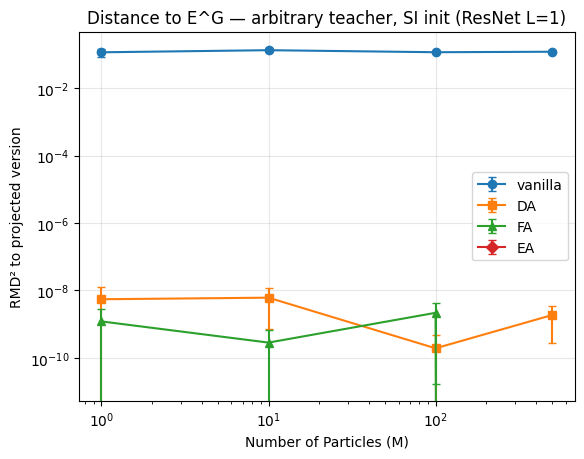

In [24]:
for name in results_arb:
    means = [jnp.mean(jnp.array(r)) for r in results_arb[name]]
    stds = [jnp.std(jnp.array(r)) for r in results_arb[name]]
    plt.errorbar(L_VALUES, means, yerr=stds, marker=markers[name],
                 label=name, capsize=3)

plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of Particles (M)")
plt.ylabel("RMD² to projected version")
plt.title("Distance to E^G — arbitrary teacher, SI init (ResNet L=1)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [25]:
teacher = make_wi_particles_resnet(1)
N = 5
L = 500
key = jax.random.PRNGKey(42)

configs = {**DEFAULT_CONFIG_RESNET, "T": 1.0, "gr": 10}

h_vanilla = train_resnet(teacher, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
h_da = train_resnet(teacher, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
print("DA done")
h_fa = train_resnet(teacher, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
print("FA done")
h_ea = train_resnet(teacher, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
print("EA done")

vanilla done
DA done
FA done
EA done


In [34]:
import plotly.graph_objects as go

def plot_particles_3d(history, teacher_particles, title):
    """3D scatter with a slider to browse training snapshots.

    A translucent plane shows (the visible part of) the G-invariant subspace E^G.
    In the matrix setup, E^G = {z : z = P z P} = {[[a,b],[b,a]]}, i.e. z2 = z3
    AND z1 = z4. The plane is drawn at z2 = z3 and its surface is colored by
    z4 = z1 (the value z4 must take for a point on the plane to actually be
    in E^G), using the same Viridis colormap as the student markers.

    Args:
        history:           dict returned by train_resnet (contains "particles" and "steps")
        teacher_particles: (N*, 2, 2) teacher particles
        title:             plot title
    """
    snapshots = history["particles"]   # list of (L, M, 2, 2)
    steps     = history["steps"]       # list of ints

    T = jnp.array(teacher_particles).reshape(-1, 4)

    # — invariant plane z2 = z3 over [-0.6, 0.6]^2, colored by z4 = z1 —
    lo, hi = -0.6, 0.6
    plane = go.Mesh3d(
        x=[lo, hi, hi, lo],
        y=[lo, lo, hi, hi],
        z=[lo, lo, hi, hi],
        i=[0, 0], j=[1, 2], k=[2, 3],
        intensity=[lo, hi, hi, lo],   # z4 = z1 on E^G
        colorscale='Viridis',
        cmin=-0.6, cmax=0.6,
        showscale=False,
        opacity=0.35,
        name='E^G (z2 = z3)',
        showlegend=True,
        hoverinfo='name',
    )

    # — build one frame per snapshot —
    frames = []
    for i, (snap, step) in enumerate(zip(snapshots, steps)):
        sp = jnp.array(snap)
        if sp.ndim == 4:
            sp = sp.reshape(-1, 2, 2)
        S = sp.reshape(-1, 4)

        frames.append(go.Frame(
            data=[
                go.Scatter3d(
                    x=S[:, 0], y=S[:, 1], z=S[:, 2],
                    mode='markers',
                    marker=dict(size=2, color=S[:, 3], colorscale='Viridis',
                                colorbar=dict(title='z4'), cmin=-0.6, cmax=0.6),
                    name='Student',
                ),
                go.Scatter3d(
                    x=T[:, 0], y=T[:, 1], z=T[:, 2],
                    mode='markers',
                    marker=dict(size=6, color=T[:, 3], colorscale='Viridis',
                                symbol='diamond', cmin=-0.6, cmax=0.6,
                                line=dict(width=1, color='black')),
                    name='Teacher',
                ),
                plane,
            ],
            name=str(step),
        ))

    # — initial figure (first snapshot) —
    fig = go.Figure(data=frames[0].data, frames=frames)

    # — slider —
    slider_steps = []
    for i, step in enumerate(steps):
        slider_steps.append(dict(
            method="animate",
            args=[[str(step)], dict(mode="immediate",
                                    frame=dict(duration=0, redraw=True),
                                    transition=dict(duration=0))],
            label=str(step),
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='z1', yaxis_title='z2', zaxis_title='z3',
            xaxis=dict(range=[-0.6, 0.6]),
            yaxis=dict(range=[-0.6, 0.6]),
            zaxis=dict(range=[-0.6, 0.6]),
        ),
        sliders=[dict(
            active=0,
            currentvalue=dict(prefix="Step: "),
            pad=dict(t=50),
            steps=slider_steps,
        )],
        width=700, height=600,
    )
    fig.show()


In [35]:
plot_particles_3d(h_vanilla, teacher, "Student Particles — vanilla (ResNet L=1)")

In [36]:
plot_particles_3d(h_da, teacher, "Student Particles — DA (ResNet L=1)")

In [37]:
plot_particles_3d(h_fa, teacher, "Student Particles — FA (ResNet L=1)")

In [38]:
plot_particles_3d(h_ea, teacher, "Student Particles — EA (ResNet L=1)")

In [13]:
teacher_arb2 = make_arbitrary_particles_resnet(L)

h_vanilla_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 0), configs, "si")
print("vanilla done")
h_da_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 1), configs, "si", used_loss_fn=loss_fn_da_resnet)
print("DA done")
h_fa_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 2), configs, "si", used_loss_fn=loss_fn_fa_resnet)
print("FA done")
h_ea_arb = train_resnet(teacher_arb2, N, L, jax.random.fold_in(key, 3), configs, "si", used_loss_fn=loss_fn_ea_resnet)
print("EA done")

vanilla done
DA done
FA done
EA done


In [14]:
plot_particles_3d(h_vanilla_arb, teacher_arb2, "Arbitrary teacher — vanilla (ResNet L=1)")

In [15]:
plot_particles_3d(h_da_arb, teacher_arb2, "Arbitrary teacher — DA (ResNet L=1)")

In [16]:
plot_particles_3d(h_fa_arb, teacher_arb2, "Arbitrary teacher — FA (ResNet L=1)")

In [17]:
plot_particles_3d(h_ea_arb, teacher_arb2, "Arbitrary teacher — EA (ResNet L=1)")

In [67]:
import numpy as np

h_vanilla['particles'][-1][0].mean()

Array(-1.6908746, dtype=float32)